In [1]:
import torch
from model import AttentionMILModel
import matplotlib.pyplot as plt
from image_patcher import ImagePatcher
from argparse import ArgumentParser
import yaml
from typing import Dict
import albumentations as A
from dataset import MILDataset
from data_utils import create_dataloader, collate_fn
import torch.nn.functional as F
import numpy as np
import pydicom
from model_utils import build_model

In [ ]:
CKPT_PATH = "mil_model.pth"
DATA_CSV_PATH = "test.csv"

In [3]:
# device = "cuda" if torch.cuda.is_available() else "cpu"
device = "cpu"

In [4]:
# Parses train config defined as yaml file
def parse_test_config() -> Dict:
    with open("config/test_config.yaml", "r") as f:
        test_config = yaml.safe_load(f)
    return test_config

In [5]:
test_config = parse_test_config()

In [6]:
state_dict = torch.load(CKPT_PATH, weights_only=True, map_location="cpu")
state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

model = build_model(output_dim=1, att_dim=test_config["attention_dim"], dropout_rate=0.5, is_ddp=False, rank=0, local_rank=0, device=device, state_dict=state_dict)
model.load_state_dict(state_dict)

<All keys matched successfully>

In [7]:
image_patcher = ImagePatcher(patch_size=test_config["patch_size"], overlap=test_config["overlap"])
test_dataset = MILDataset(DATA_CSV_PATH, image_patcher=image_patcher)

/users/scratch1/s189737/attention/mil/diabetic_retinopathy/dataset.py:31: DtypeWarning: Columns (29,33,47,48,49,50,51,61,77,80,85,86,91,92,93,94,95,97,119,120,121,122,123,292) have mixed types. Specify dtype option on import or set low_memory=False.
  self.df = pd.read_csv(dataset_csv)


In [29]:
index = torch.argwhere(test_dataset.labels == 1)[0]

In [30]:
image_path = test_dataset.df.iloc[index.item()].new_path

In [32]:
if image_path.endswith(".dcm"):
    image = pydicom.dcmread(image_path).pixel_array
else:
    image = plt.imread(image_path)

In [33]:
features, labels, masks, bags_length, instances_idx, instances_cords = collate_fn([test_dataset[index.item()]])

In [34]:
output, att = model(features, masks, bags_length, return_att=True)

In [35]:
print(f"Output: {F.sigmoid(output)}, Label: {labels}")

Output: tensor([0.9606], grad_fn=<SigmoidBackward0>), Label: tensor([1])


In [36]:
h, w = image.shape

In [37]:
n_instances = features.shape[0]
# att_expanded = att.view(n_instances, 1, 1, 1)
# att_patches = att_expanded.expand(n_instances, 3, 224, 224)  

In [38]:
att_patches = att.reshape((1, 1, 1, att.shape[1]))

In [39]:
reconstructed_image = image_patcher.reconstruct_image_from_patches(features, instances_idx[0], (3, h, w))
att_reconstructed = image_patcher.reconstruct_attention_map(att_patches, instances_idx[0], (h, w))

In [40]:
# att_reconstructed = (att_reconstructed - att_reconstructed.min()) / (att_reconstructed.max() - att_reconstructed.min())
# att_reconstructed *= 255
# att_reconstructed = att_reconstructed.to(torch.long)

Text(0.5, 1.0, 'Mapa atencji')

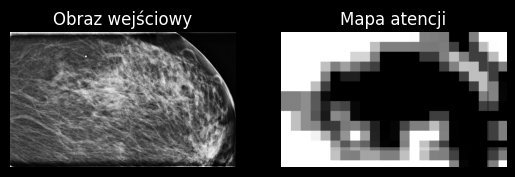

In [41]:
fig, axs = plt.subplots(1, 2)

axs[0].imshow(reconstructed_image.permute(1, 2, 0))
axs[0].axis('off')
axs[0].set_title("Obraz wejściowy")

axs[1].imshow(att_reconstructed.detach().squeeze().numpy(), cmap='gray')
axs[1].axis('off')
axs[1].set_title("Mapa atencji")